# 07 — What is in the cube, and does it hold together?

Reads `data/processed/flood_cube_*.nc` and answers three questions before any modelling:

1. **What is in the file** — variables, units, ranges, missing data (printed as a table).
2. **Does it look like Bangladesh** — mean-state maps, and the monsoon in the time series.
3. **Do inputs and labels agree** — flood fraction binned against each GloFAS driver. If the labels
   were mis-gridded, this is where it shows: the relationship would be flat.

Every panel carries **one measure on one axis**. Discharge and flooded area differ by orders of
magnitude; putting them on twin axes would let the eye read a correlation that the scaling invented.

In [1]:
# ============================================================
# CELL 1 - Load + describe
# ============================================================
from pathlib import Path
import glob

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from paths import PROCESSED

NC = sorted(PROCESSED.glob("flood_cube_*.nc"))[-1]
ds = xr.open_dataset(NC, engine="h5netcdf")

# --- palette: slots 1-3 of the validated reference palette, in documented order ---
C_INPUT, C_LABEL, C_AUX = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED = "#0b0b0b", "#52514e"
plt.rcParams.update({
    "font.size": 10, "axes.edgecolor": "#c9c9c4", "axes.labelcolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False,
    "axes.spines.right": False, "grid.color": "#e8e8e4", "grid.linewidth": 0.8,
    "figure.facecolor": "white", "axes.titlesize": 10,
})

rows = []
for v in ds.data_vars:
    a = ds[v].values.astype("float64")
    if v == "flood_binary":
        a = np.where(a == -1, np.nan, a)
    rows.append({
        "variable": v,
        "units": ds[v].attrs.get("units", "-"),
        "min": np.nanmin(a), "median": np.nanmedian(a), "max": np.nanmax(a),
        "missing %": np.isnan(a).mean() * 100,
        "source": ds[v].attrs.get("source", "-").split("(")[0].strip(),
    })
print(f"file : {Path(NC).name}  ({Path(NC).stat().st_size/1e6:.1f} MB)")
print(f"dims : {dict(ds.sizes)}")
print(f"grid : lat {ds.latitude.values[-1]:.3f}..{ds.latitude.values[0]:.3f}  "
      f"lon {ds.longitude.values[0]:.3f}..{ds.longitude.values[-1]:.3f}  @ 0.05 deg")
print(f"time : {str(ds.time.values[0])[:10]} .. {str(ds.time.values[-1])[:10]}\n")
pd.set_option("display.width", 130)
print(pd.DataFrame(rows).to_string(index=False,
      formatters={"min": "{:.3f}".format, "median": "{:.3f}".format,
                  "max": "{:.3f}".format, "missing %": "{:.1f}".format}))

/opt/anaconda3/envs/sia/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gmt' loading failed:
Error loading GMT shared library at 'libgmt.dylib'.
dlopen(libgmt.dylib, 0x0006): tried: 'libgmt.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibgmt.dylib' (no such file), '/opt/anaconda3/envs/sia/lib/python3.11/lib-dynload/../../libgmt.dylib' (no such file), '/opt/anaconda3/envs/sia/bin/../lib/libgmt.dylib' (no such file), '/usr/lib/libgmt.dylib' (no such file, not in dyld cache), 'libgmt.dylib' (no such file), '/usr/local/lib/libgmt.dylib' (no such file), '/usr/lib/libgmt.dylib' (no such file, not in dyld cache)
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


file : flood_cube_bd_ne_india_2022-05-01_to_2022-08-31.nc  (19.0 MB)
dims : {'time': 123, 'latitude': 130, 'longitude': 140}
grid : lat 21.025..27.475  lon 87.025..93.975  @ 0.05 deg
time : 2022-05-01 .. 2022-08-31

      variable    units   min median        max missing %              source
     discharge   m3 s-1 0.000  2.469 104540.281       0.0    GloFAS-ERA5 v4.0
        runoff mm day-1 0.000  3.230    222.754       0.0    GloFAS-ERA5 v4.0
  soil_wetness        1 0.205  0.842      0.987       0.0    GloFAS-ERA5 v4.0
flood_fraction        1 0.000  0.000      1.000      58.0 MODIS MCDWD_L3 v061
  flood_binary        - 0.000  0.000      1.000      58.0 MODIS MCDWD_L3 v061
valid_fraction        1 0.000  0.062      1.000       0.0 MODIS MCDWD_L3 v061


## 1 — Mean state

One map per variable, each on its own **single-hue** ramp: magnitude reads as light-to-dark, so
there is no rainbow to decode. Discharge is log-scaled because a river network spans orders of
magnitude and a linear ramp would show only the Brahmaputra.

/var/folders/0v/kq5zkcp967549h0tw3576nzm0000gr/T/ipykernel_72057/3091399114.py:14: RuntimeWarning: Mean of empty slice
  m = np.nanmean(ds[v].values, axis=0)


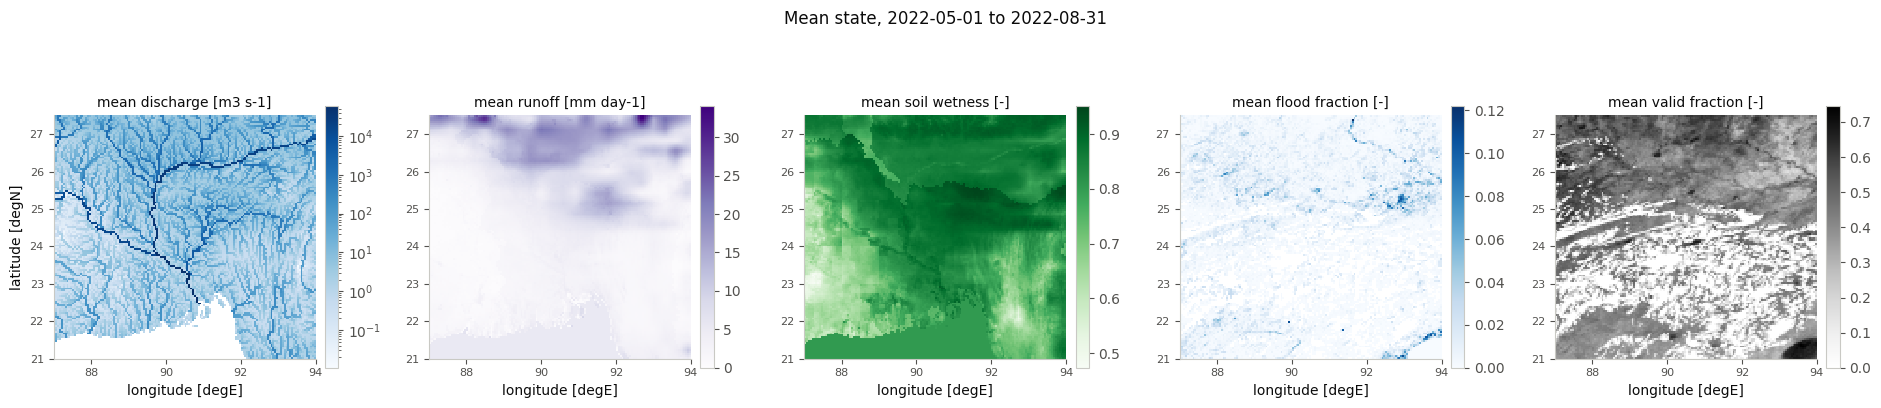

In [2]:
# ============================================================
# CELL 2 - Mean-state maps
# ============================================================
from matplotlib.colors import LogNorm

PANELS = [("discharge",      "Blues",   True,  "mean discharge [m3 s-1]"),
          ("runoff",         "Purples", False, "mean runoff [mm day-1]"),
          ("soil_wetness",   "Greens",  False, "mean soil wetness [-]"),
          ("flood_fraction", "Blues",   False, "mean flood fraction [-]"),
          ("valid_fraction", "Greys",   False, "mean valid fraction [-]")]

fig, axes = plt.subplots(1, len(PANELS), figsize=(19, 3.9))
for ax, (v, cmap, log, title) in zip(axes, PANELS):
    m = np.nanmean(ds[v].values, axis=0)
    kw = dict(cmap=cmap, shading="nearest")
    if log:
        kw["norm"] = LogNorm(vmin=max(np.nanmin(m[m > 0]), 1e-2), vmax=np.nanmax(m))
    im = ax.pcolormesh(ds.longitude, ds.latitude, m, **kw)
    ax.set_title(title, color=INK)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.03)
axes[0].set_ylabel("latitude [degN]")
for ax in axes:
    ax.set_xlabel("longitude [degE]")
fig.suptitle("Mean state, 2022-05-01 to 2022-08-31", y=1.04, fontsize=12, color=INK)
fig.tight_layout()
plt.show()

## 2 — The monsoon in time

Five stacked panels, **one measure each**, sharing a time axis. The bottom panel is the honesty
check: MODIS coverage collapses exactly when the flooding peaks, so a low flooded-area value on a
low-coverage day means *not seen*, not *not flooded*.

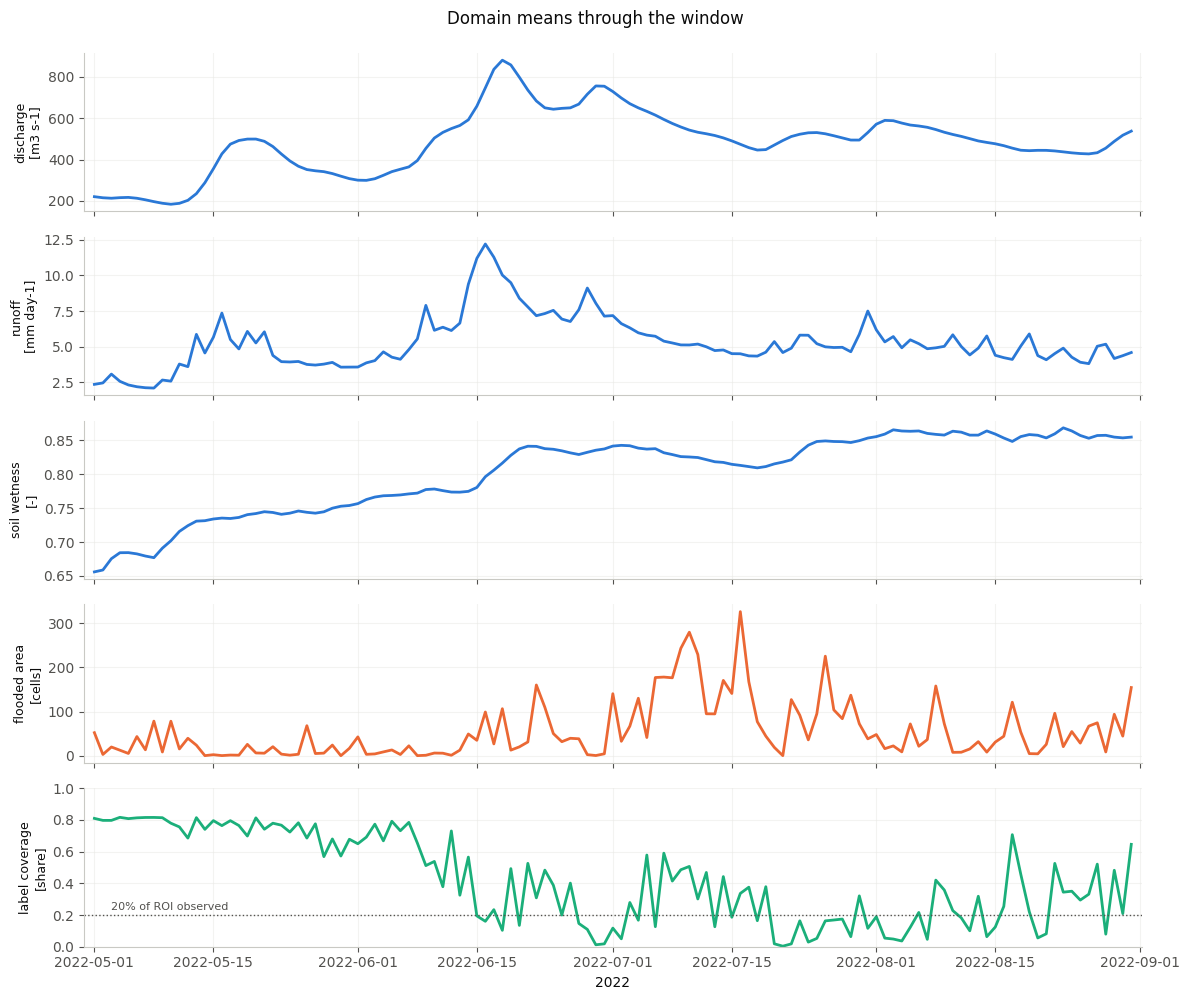

In [3]:
# ============================================================
# CELL 3 - Domain-mean time series (one measure per axis - never twinned)
# ============================================================
t     = pd.to_datetime(ds.time.values)
ff    = ds.flood_fraction.values
series = [
    ("discharge",     np.nanmean(ds.discharge.values,    axis=(1, 2)), "m3 s-1",   C_INPUT),
    ("runoff",        np.nanmean(ds.runoff.values,       axis=(1, 2)), "mm day-1", C_INPUT),
    ("soil wetness",  np.nanmean(ds.soil_wetness.values, axis=(1, 2)), "-",        C_INPUT),
    ("flooded area",  np.nansum(np.where(np.isfinite(ff), ff, 0), axis=(1, 2)),
                                                                       "cells",    C_LABEL),
    ("label coverage", np.isfinite(ff).mean(axis=(1, 2)),              "share",    C_AUX),
]

fig, axes = plt.subplots(len(series), 1, figsize=(12, 10), sharex=True)
for ax, (name, y, unit, c) in zip(axes, series):
    ax.plot(t, y, color=c, linewidth=2)          # single series -> title names it, no legend
    ax.set_ylabel(f"{name}\n[{unit}]", fontsize=9)
    ax.grid(alpha=0.5, linewidth=0.8)
    ax.margins(x=0.01)
axes[-1].set_ylim(0, 1)
axes[-1].axhline(0.2, color=MUTED, linestyle=":", linewidth=1)
axes[-1].text(t[2], 0.23, "20% of ROI observed", fontsize=8, color=MUTED)
axes[-1].set_xlabel("2022")
fig.suptitle("Domain means through the window", y=0.995, fontsize=12, color=INK)
fig.tight_layout()
plt.show()

## 3 — The peak day

The day with the largest observed flooded area, shown as small multiples: the driver, the label,
and how much of the scene MODIS could actually see.

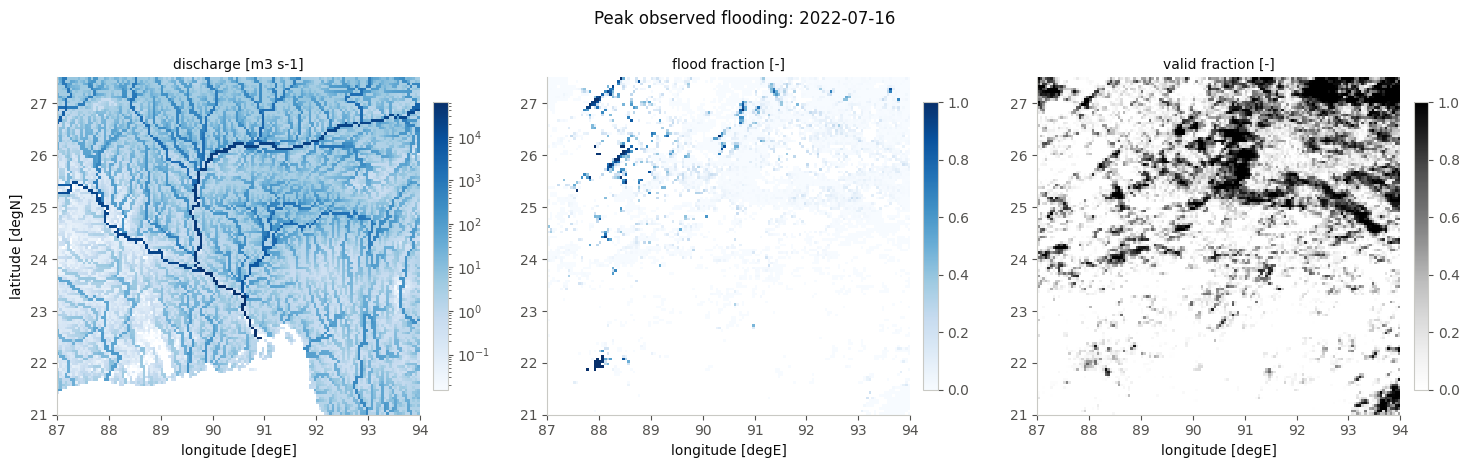

peak day 2022-07-16: flooded area 326 cells, coverage 34% of ROI


In [4]:
# ============================================================
# CELL 4 - Peak flood day
# ============================================================
area = np.nansum(np.where(np.isfinite(ff), ff, 0), axis=(1, 2))
pk   = int(np.argmax(area))
day  = str(ds.time.values[pk])[:10]

PK = [("discharge",      "Blues", True,  "discharge [m3 s-1]"),
      ("flood_fraction", "Blues", False, "flood fraction [-]"),
      ("valid_fraction", "Greys", False, "valid fraction [-]")]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, (v, cmap, log, title) in zip(axes, PK):
    m  = ds[v].values[pk]
    kw = dict(cmap=cmap, shading="nearest")
    if log:
        kw["norm"] = LogNorm(vmin=max(np.nanmin(m[m > 0]), 1e-2), vmax=np.nanmax(m))
    else:
        kw.update(vmin=0, vmax=1)
    im = ax.pcolormesh(ds.longitude, ds.latitude, m, **kw)
    ax.set_title(title, color=INK); ax.set_aspect("equal"); ax.set_xlabel("longitude [degE]")
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.03)
axes[0].set_ylabel("latitude [degN]")
fig.suptitle(f"Peak observed flooding: {day}", y=1.02, fontsize=12, color=INK)
fig.tight_layout()
plt.show()
print(f"peak day {day}: flooded area {area[pk]:.0f} cells, "
      f"coverage {np.isfinite(ff[pk]).mean()*100:.0f}% of ROI")

## 4 — Do the labels track the drivers?

**Not cell by cell — that test is rigged.** `FLOOD_CLASSES = (2, 3)` counts inundation *beyond*
permanent water, so MCDWD class 1 (the river channel itself) is excluded. Discharge is highest in
exactly those channel cells, so a per-cell comparison scores the label where it is defined to be
zero and returns a spurious negative. The table below shows it: mean flood fraction is flat across
discharge deciles and *lowest* in the main channels.

The test that means something is **temporal and lagged**, and it must be run two ways:

- **Raw series** — both the drivers and the flooded area climb through the monsoon, so a positive
  correlation here can be nothing more than shared seasonality.
- **First differences** — day-to-day *changes*, which removes that shared trend and asks the harder
  question: when a driver jumps, does the flooded area jump a few days later?

Read both panels before trusting either.

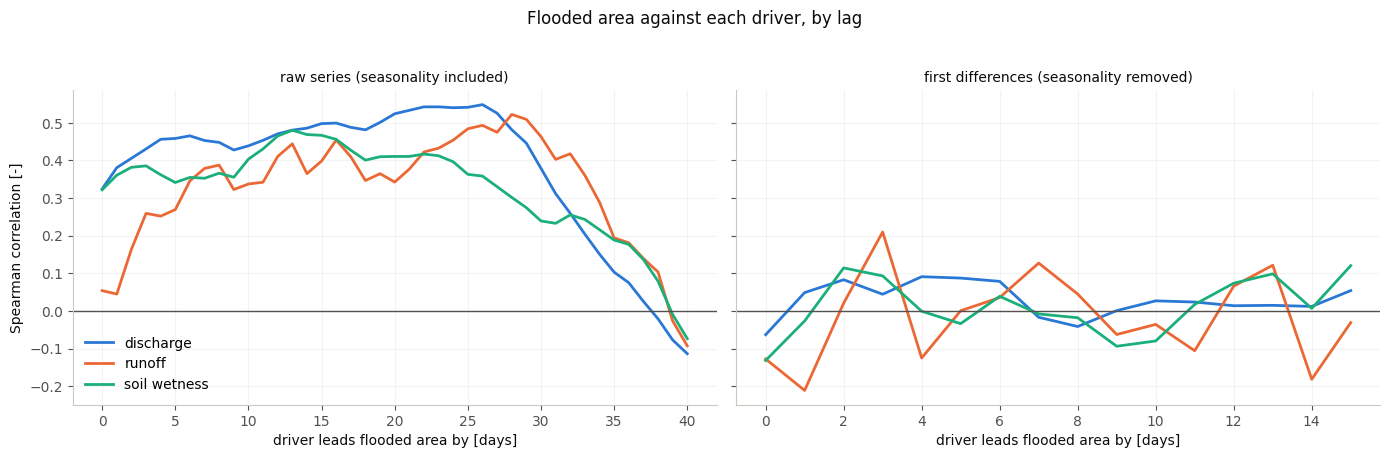

driver          raw: best rho  at lag   |  diff: best rho  at lag
discharge              +0.548      26   |          +0.091       4
runoff                 +0.522      28   |          +0.210       3
soil_wetness           +0.480      13   |          +0.120      15

mean flood_fraction by mean-discharge band (flat = the per-cell test carries no signal):
   below median               n= 9100 cells   0.0068
   p90-p99                    n= 1638 cells   0.0070
   p99-p99.9                  n=  163 cells   0.0084
   top 0.1% (main channels)   n=   19 cells   0.0028


In [5]:
# ============================================================
# CELL 5 - Labels vs drivers: lagged, raw and detrended
# ============================================================
area = np.nansum(np.where(np.isfinite(ff), ff, 0), axis=(1, 2))
dom  = {v: np.nanmean(ds[v].values, axis=(1, 2)) for v in ("discharge", "runoff", "soil_wetness")}
COLORS = {"discharge": C_INPUT, "runoff": C_LABEL, "soil_wetness": C_AUX}

def spearman(a, b):
    return np.corrcoef(np.argsort(np.argsort(a)), np.argsort(np.argsort(b)))[0, 1]

def lag_curve(x, y, lags):
    """Correlation of x leading y by each lag."""
    return np.array([spearman(x[:len(x) - L] if L else x, y[L:]) for L in lags])

LAGS_RAW  = np.arange(0, 41)      # long enough to show the turnover, not just a rising edge
LAGS_DIFF = np.arange(0, 16)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
for v, y in dom.items():
    axes[0].plot(LAGS_RAW,  lag_curve(y, area, LAGS_RAW),
                 color=COLORS[v], linewidth=2, label=v.replace("_", " "))
    axes[1].plot(LAGS_DIFF, lag_curve(np.diff(y), np.diff(area), LAGS_DIFF),
                 color=COLORS[v], linewidth=2, label=v.replace("_", " "))
for ax, ttl in zip(axes, ["raw series (seasonality included)",
                          "first differences (seasonality removed)"]):
    ax.axhline(0, color=MUTED, linewidth=1)
    ax.set_xlabel("driver leads flooded area by [days]")
    ax.set_title(ttl, color=INK)
    ax.grid(alpha=0.5, linewidth=0.8)
    ax.set_axisbelow(True)
axes[0].set_ylabel("Spearman correlation [-]")
axes[0].legend(frameon=False, loc="lower left")
fig.suptitle("Flooded area against each driver, by lag", y=1.03, fontsize=12, color=INK)
fig.tight_layout()
plt.show()

print(f"{'driver':<14}{'raw: best rho':>15}{'at lag':>8}{'   |':>4}{'diff: best rho':>16}{'at lag':>8}")
for v, y in dom.items():
    r, d = lag_curve(y, area, LAGS_RAW), lag_curve(np.diff(y), np.diff(area), LAGS_DIFF)
    print(f"{v:<14}{r.max():>+15.3f}{LAGS_RAW[r.argmax()]:>8d}{'   |':>4}"
          f"{d.max():>+16.3f}{LAGS_DIFF[d.argmax()]:>8d}")

# Why the per-cell test fails: the label excludes the channel, where discharge lives.
mdis = np.nanmean(ds.discharge.values, axis=0)
q    = np.nanpercentile(mdis, [50, 90, 99, 99.9])
print("\nmean flood_fraction by mean-discharge band (flat = the per-cell test carries no signal):")
for lo, hi, nm in [(0, q[0], "below median"), (q[1], q[2], "p90-p99"),
                   (q[2], q[3], "p99-p99.9"), (q[3], np.inf, "top 0.1% (main channels)")]:
    m = (mdis >= lo) & (mdis < hi)
    print(f"   {nm:26s} n={m.sum():5d} cells   {np.nanmean(ff[:, m]):.4f}")

## Verdict

- **Geometry is right.** The discharge map draws the Ganges, Brahmaputra and Meghna where they
  belong, and the labels sit on the same grid by construction (notebook 06 asserts it).
- **Seasonally the two agree** — every driver correlates ~+0.5 with flooded area at a lag of a few
  weeks, and the correlation decays and reverses beyond that, which is the shape a monsoon should
  give.
- **At event scale there is no usable signal.** Once the shared seasonal trend is differenced out,
  the correlations fall to noise. With 58% of label day-cells missing and coverage swinging between
  0 and 0.8 from one day to the next, day-to-day flooded area mostly records *whether MODIS could
  see the ground*, not whether water was on it.

That is a property of optical flood mapping in a monsoon, not of this pipeline. Training a
day-scale model on `flood_fraction` as it stands would largely be fitting cloud. The options are to
aggregate to multi-day composites, weight the loss by `valid_fraction`, or move the label to
Sentinel-1 SAR, which sees through cloud.